<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> 
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
try:
   from astropy.table import vstack
except:
   !pip install astropy
   from astropy.table import vstack
try:
   from astroquery.gaia import Gaia
except:
   !pip install astroquery
   from astroquery.gaia import Gaia

color_classes = {'RR': 'C0', 'CEP': 'C1', 'DSCT': 'C2'}

rc_params = {
    # --- Fonts and text ---
    'mathtext.fontset': 'cm',     # Set default mathtext font
    'font.family': 'STIXGeneral', # Set default font family
    
    # --- Figure and axes ---
    'font.size': 12,              # Set default font size
    'axes.labelsize': 16,         # Set default axes label size
    'axes.titlesize': 16,         # Set default axes title size
    'xtick.labelsize': 14,        # Set default axes label size
    'ytick.labelsize': 14,        # Set default axes label size
    'legend.fontsize': 14,        # Set default legend font size
    
    # --- Configuration of ticks ---
    'xtick.direction': 'in',      # Set default xtickdirecion
    'ytick.direction': 'in',      # Set default ytickdirecion
    'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
    'ytick.minor.visible': True,  # visibility of minor ticks on y-axis


    'grid.linestyle': ':',        # Set grid linestyle
    'grid.alpha': 0.6,            # Set grid transparency
    
    # --- Figure size ---
    'figure.figsize': (8, 6),     # Ideal proportion for one MNRAS column
}
plt.rcParams.update(rc_params)

# Supervised Machine Learning
---
At its core, **Supervised Learning** is the process of training an algorithm using a dataset that already contains the "right answers." These answers are known as labels. Think of it as a student learning a subject with a comprehensive answer key at their side; the model examines the input data, makes a guess, and then uses the label to correct itself until it masters the pattern.The fundamental goal is to define a mathematical mapping function, $f$, that connects your input features ($X$) to a specific target output ($y$):

$$y = f(X) + \epsilon$$

Where:
- $X$ (Features): The independent variables or observations (e.g., the period and color of a star).
- $y$ (Labels): The ground truth we want to predict (e.g., the classification of that star).
- $\epsilon$ (Error): The inevitable noise or irreducible error in the data.Once the training phase is complete, the "supervisor" (the labels) is removed. 

The model is then expected to take new, unseen data and accurately predict the output based on the logic it discovered during its education. Whether you are predicting a category (**Classification**) or a continuous value (**Regression**).

# Classification
---

In this project, we utilize data from Gaia DR3 to perform a classification task on Variable Stars. These are celestial objects that exhibit fluctuations in their luminosity over time.

We focus on the three most common types found in the Gaia catalogs:

- **Cepheids (CEP):** High-mass, highly luminous stars (giants and supergiants). They occupy the upper section of the instability strip in the HR diagram.

- **RR Lyrae (RR):** Older, low-mass stars. They are less luminous than Cepheids and are typically found on the "Horizontal Branch."

- **Delta Scuti (DSCT):** Stars located on the Main Sequence or slightly evolved from it. They exhibit lower luminosity compared to the previous classes and higher frequencies in their pulsations.

![](Figures/hr_diagram_variable_stars.png)

In [3]:
from astroquery.utils.tap.core import TapPlus
aip_gaia = TapPlus(url="https://gaia.aip.de/tap")

In [4]:
import time
import logging
logging.getLogger('astroquery').setLevel(logging.ERROR)
n_samples = 500 
tables = []
classes = ['RR', 'CEP', 'DSCT|GDOR|SXPHE']


for cls in classes:
    for attempt in range(3):  # max 3 attempts
        try:
            q = f"""
            SELECT TOP {n_samples}
                g.source_id, g.ra, g.dec, g.parallax, g.pmra, g.pmdec,
                g.phot_g_mean_mag, g.bp_rp,
                v.best_class_name AS target_class
            FROM gaiadr3.gaia_source AS g
            JOIN gaiadr3.vari_classifier_result AS v
                ON g.source_id = v.source_id
            WHERE g.parallax_over_error > 5
                AND g.bp_rp IS NOT NULL
                AND v.best_class_name = '{cls}'
            ORDER BY g.random_index
            """
            #job = Gaia.launch_job_async(q)
            job = Gaia.launch_job(q)
            t   = job.get_results()
            if len(t) > 0:
                tables.append(t)
            print(f"✓ {cls}: {len(t)} rows")
            break  # success, exit the retry loop
        except Exception as e:
            print(f"✗ {cls} attempt {attempt+1}: {e}")
            time.sleep(10)  # wait 10s before retrying

print("\n[2] Stacking tables (vstack)...")
results = vstack(tables)

# Convert to Pandas
df = results.to_pandas()
df['target_class'] = df['target_class'].apply(
    lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x)
)
# Replace the target_class values to more general categories
df.replace({'target_class': {
    'RR': 'RR',
    'CEP': 'CEP',
    'DSCT|GDOR|SXPHE': 'DSCT',
}}, inplace=True)

✓ RR: 500 rows
✗ CEP attempt 1: Error 500: 
(TAP) Cannot execute query 'SELECT "g"."source_id" AS "source_id" , "g"."ra" AS "ra" , "g"."dec" AS "dec" , "g"."parallax" AS "parallax" , "g"."pmra" AS "pmra" , "g"."pmdec" AS "pmdec" , "g"."phot_g_mean_mag" AS "phot_g_mean_mag" , "g"."bp_rp" AS "bp_rp" , "v"."best_class_name" AS "target_class"
FROM gaiadr3.gaia_source AS "g" INNER JOIN gaiadr3.vari_classifier_result AS "v" ON "g"."source_id" = "v"."source_id"
WHERE "g"."parallax_over_error" > 5 AND "g"."bp_rp" IS NOT NULL AND "v"."best_class_name" = 'CEP'
ORDER BY "g"."random_index" ASC
Limit 500' for job ' (source query: '
            SELECT TOP 500
                g.source_id, g.ra, g.dec, g.parallax, g.pmra, g.pmdec,
                g.phot_g_mean_mag, g.bp_rp,
                v.best_class_name AS target_class
            FROM gaiadr3.gaia_source AS g
            JOIN gaiadr3.vari_classifier_result AS v
                ON g.source_id = v.source_id
            WHERE g.parallax_over_error >

KeyboardInterrupt: 

In [5]:
# Connect to the VizieR TAP server
vizier_tap = TapPlus(url="http://tapvizier.cds.unistra.fr/TAPVizieR/tap")

n_samples = 500 
tables = []

# Official Gaia DR3 taxonomy
classes = ['RR', 'CEP', 'DSCT|GDOR|SXPHE']

print("Connecting to VizieR TAP...")

for cls in classes:
    for attempt in range(3):
        try:
            # FIX: Cross-match source table (I/355) with variability table (I/358)
            q = f"""
            SELECT TOP {n_samples}
                g.Source AS source_id, 
                g.RA_ICRS AS ra, 
                g.DE_ICRS AS dec, 
                g.Plx AS parallax, 
                g.pmRA AS pmra, 
                g.pmDE AS pmdec,
                g.Gmag AS phot_g_mean_mag, 
                g."BP-RP" AS bp_rp,
                v.Class AS target_class
            FROM "I/355/gaiadr3" AS g
            INNER JOIN "I/358/vclassre" AS v ON g.Source = v.Source
            WHERE (g.Plx / g.e_Plx) > 5
                AND g."BP-RP" IS NOT NULL
                AND v.Class = '{cls}'
            """
            
            # Submit the job to the server
            job = vizier_tap.launch_job(q)
            t   = job.get_results()
            
            if len(t) > 0:
                tables.append(t)
            print(f"✓ {cls}: {len(t)} rows retrieved")
            break  
        except Exception as e:
            print(f"✗ {cls} attempt {attempt+1}: {e}")
            time.sleep(10)

print("\n[2] Stacking tables (vstack)...")
if tables:
    results = vstack(tables)

    # Convert to Pandas
    df = results.to_pandas()
    
    # Clean strings in case VizieR returns text in binary format (bytes)
    df['target_class'] = df['target_class'].apply(
        lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x)
    )
    
    # Standardize names to the 3 main categories
    df.replace({'target_class': {
        'RR': 'RR',
        'CEP': 'CEP',
        'DSCT|GDOR|SXPHE': 'DSCT',
    }}, inplace=True)
    
    print("\nFinal data summary ready for MPhy-VAE / ML:")
    print(df['target_class'].value_counts())
else:
    print("No data found.")

Conectando con VizieR TAP...
✓ RR: 500 rows obtenidas
✓ CEP: 500 rows obtenidas
✓ DSCT|GDOR|SXPHE: 500 rows obtenidas

[2] Apilando tablas (vstack)...

Resumen final de datos listos para MPhy-VAE / ML:
target_class
RR      500
CEP     500
DSCT    500
Name: count, dtype: int64


In [5]:
try:
    assert not df.empty
except (NameError, AssertionError):
    df = pd.read_csv('gaia_variable_stars_classification.csv')

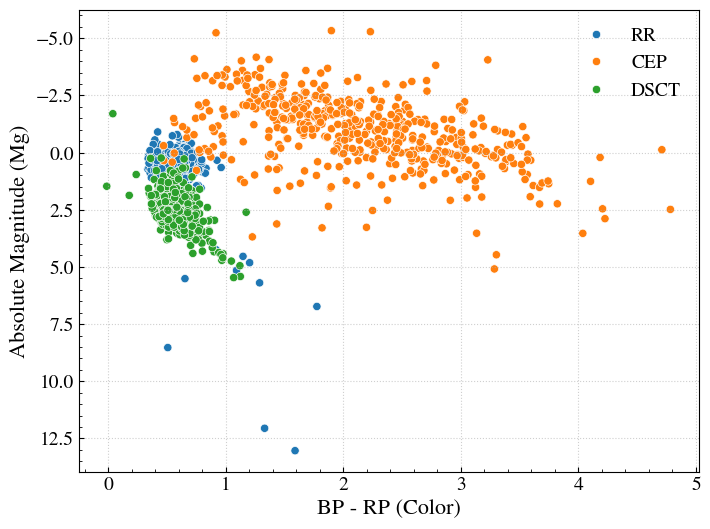

In [6]:
# Absolute Magnitude (Mg)
# Mg = G + 5 * log10(parallax) - 10
df['Mg'] = df['phot_g_mean_mag'] + 5 * np.log10(df['parallax']) - 10

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='bp_rp',
    y='Mg',
    hue='target_class',
    color=df['target_class'].map(color_classes)
)
ax.invert_yaxis()
ax.set_xlabel('BP - RP (Color)')
ax.set_ylabel('Absolute Magnitude (Mg)')
ax.legend(title='', frameon=False)
ax.grid()
plt.show()

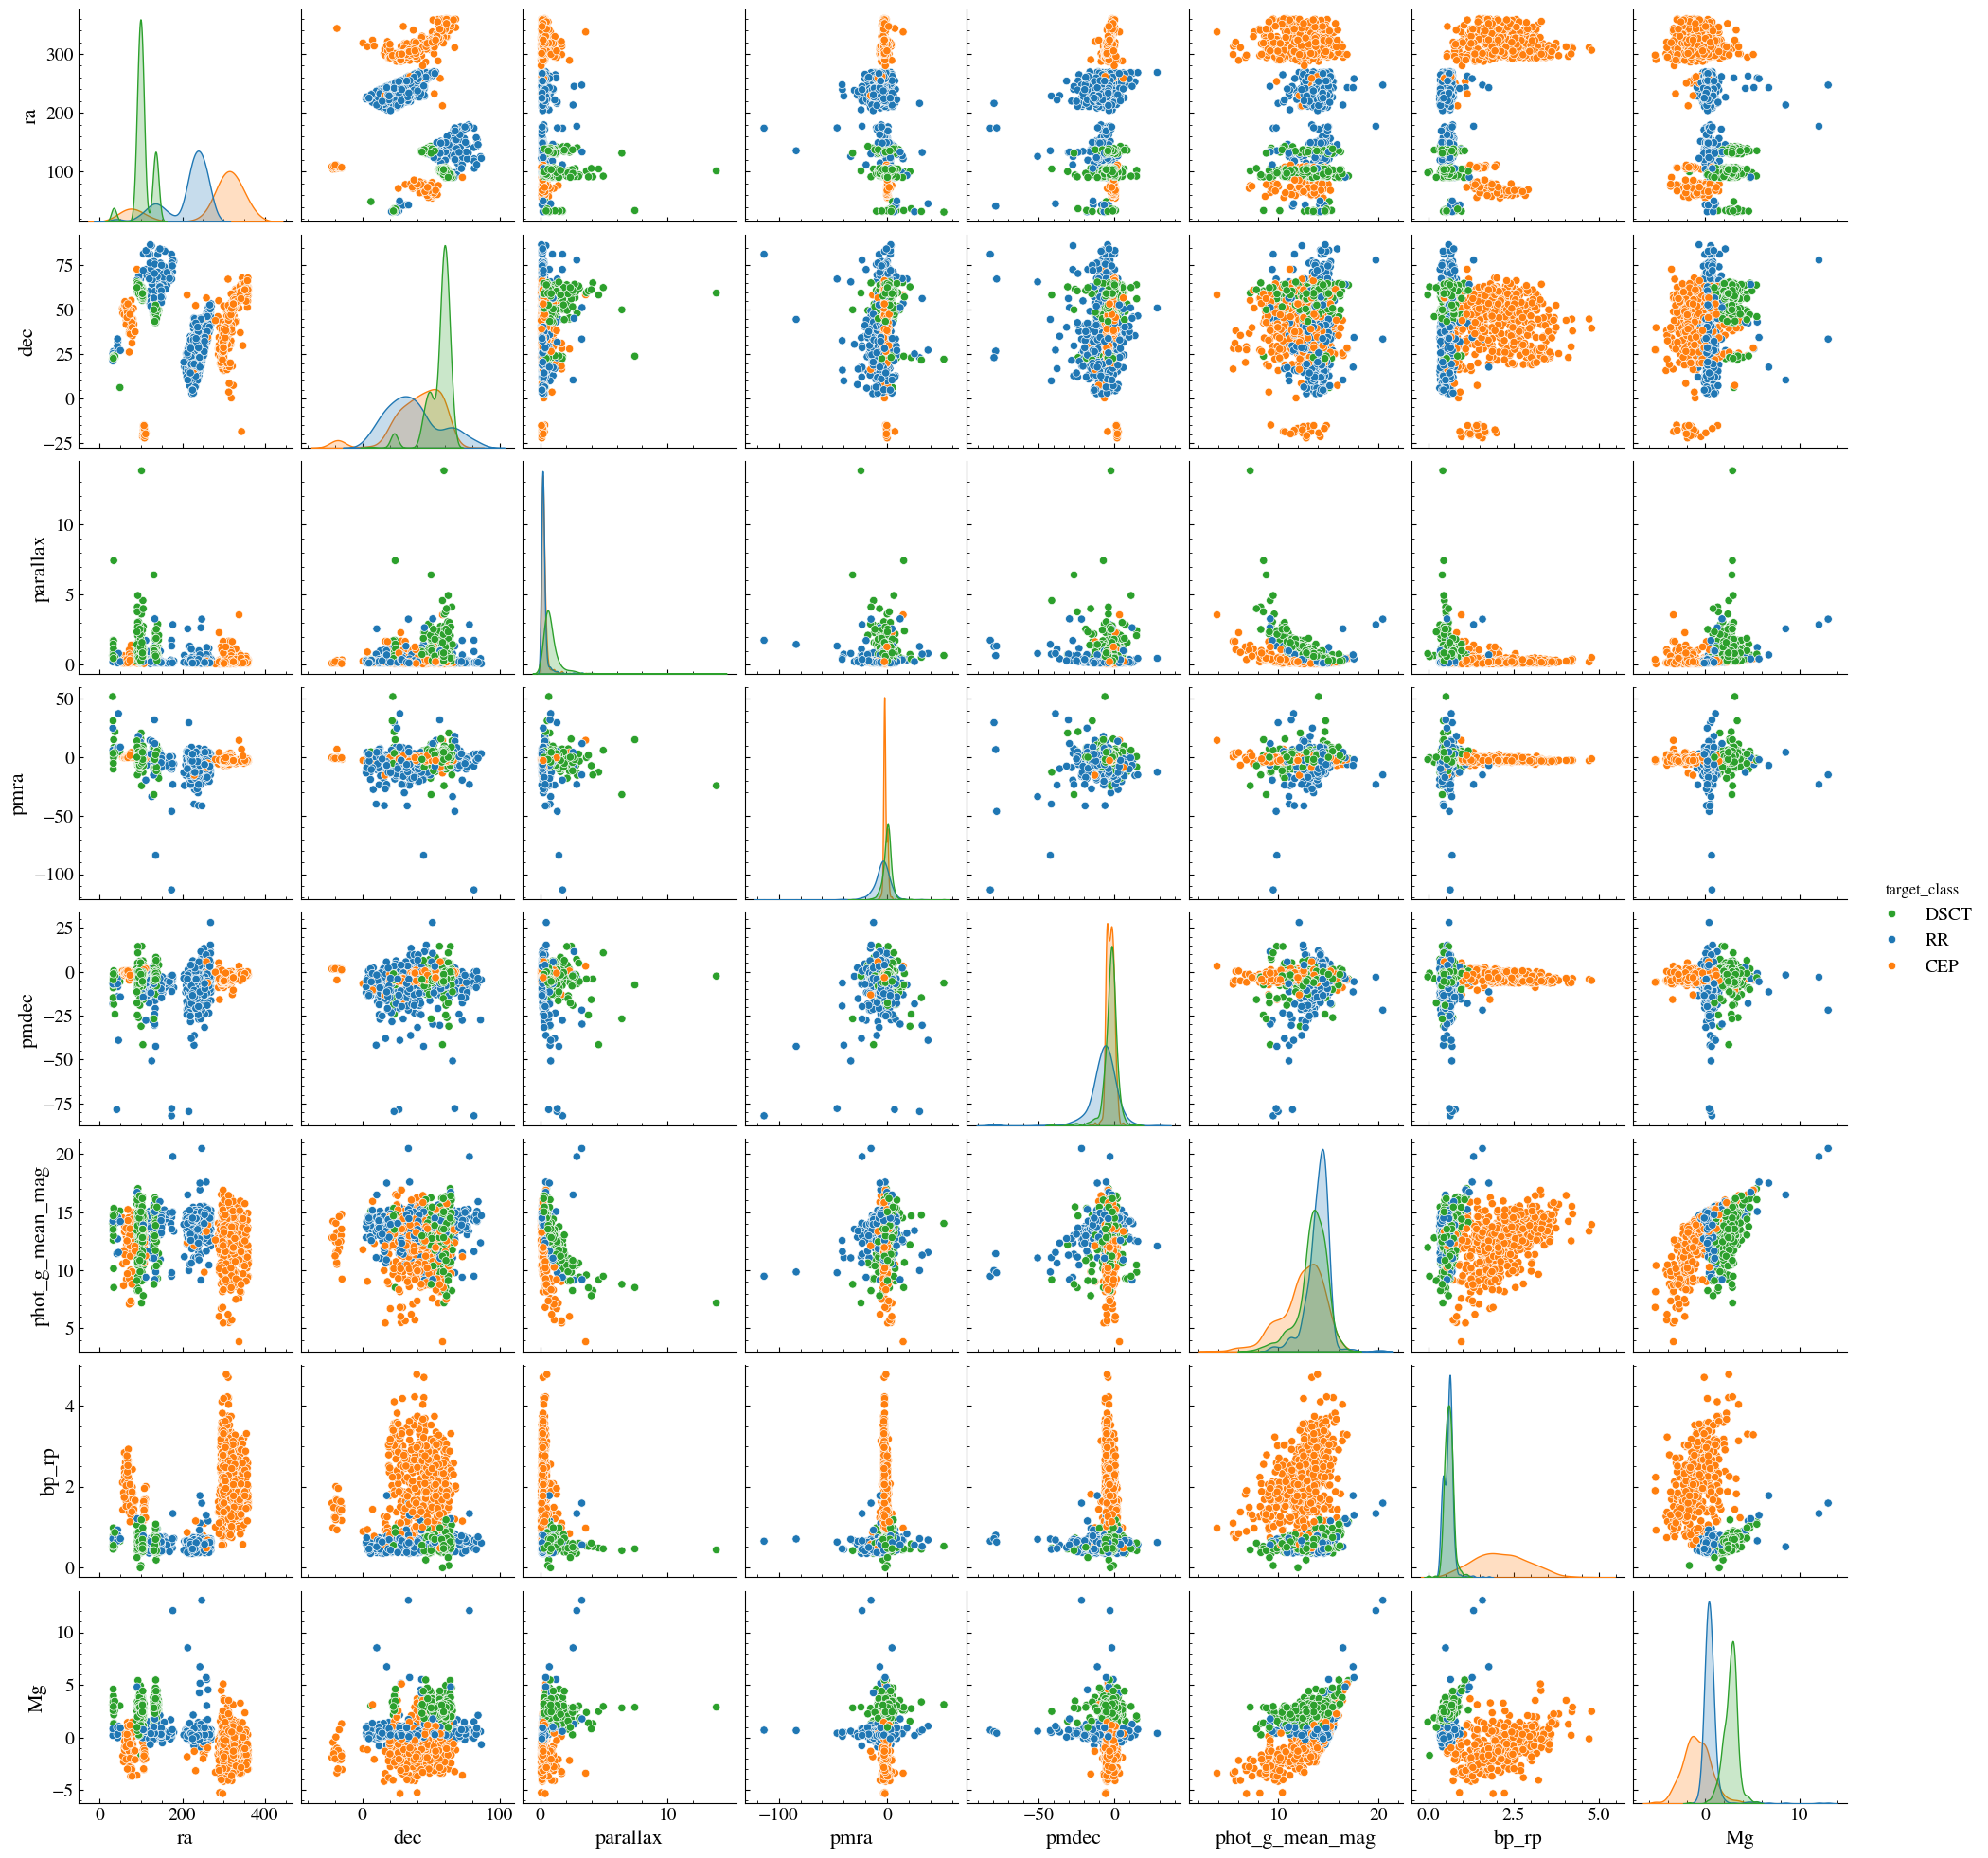

In [11]:
sns.pairplot(
    data=df,
    vars=['ra', 'dec', 'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp', 'Mg'],
    hue='target_class',
    palette=color_classes
)
plt.show()

In [12]:
# Force target_class to standard string (Astropy sometimes leaves it as bytes like b'CEP')
df['target_class'] = df['target_class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

print(f" -> Raw DataFrame size: {df.shape[0]} rows.")
print(df['target_class'].value_counts())

print("\n[4] Shuffling data...")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFinal class distribution ready for Machine Learning:")
print(df['target_class'].value_counts())

 -> Raw DataFrame size: 1500 rows.
target_class
DSCT    500
RR      500
CEP     500
Name: count, dtype: int64

[4] Shuffling data...

Final class distribution ready for Machine Learning:
target_class
RR      500
CEP     500
DSCT    500
Name: count, dtype: int64


We will begin with the classification task. First we need to defined a train and test dataset. For this we will use the library `sklearn`

## $K$-Nearest Neighbors (KNN)

The K-Nearest Neighbors (KNN) algorithm is a non-parametric supervised learning method used for classification. In the context of variable stars, the algorithm predicts the class of a target star by analyzing its $k$ closest neighbors within a multidimensional feature space (e.g., color, absolute magnitude, and parallax).

Given a labeled training set $\{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$, KNN classifies a new point $\mathbf{x}$ by finding its $k$ closest neighbors under a distance metric typically the Euclidean distance:

$$d(\mathbf{x}, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{p}(x_j - x_{i,j})^2}$$

The predicted class is the **majority vote** among the $k$ nearest neighbors:

$$\hat{y} = \underset{c}{\arg\max} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y_i = c]$$

where $\mathcal{N}_k(\mathbf{x})$ is the set of the $k$ closest points to $\mathbf{x}$

To improve performance in regions where stellar populations overlap, we can assign a weight $w_i$ to each neighbor inversely proportional to its distance:$$w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i)^2}$$This ensures that more "similar" stars have a greater influence on the classification than those at the outskirts of the $k$-neighborhood.

**Effect of $k$:**
- Small $k$ → Low bias, high variance. The model is sensitive to noise (e.g., photometric errors in Gaia DR3) and outliers.
- Large $k$ → High bias, low variance. It produces smoother decision boundaries but may overlook small-scale structures in the instability strip.

> **Important:** KNN is highly sensitive to the scale of input features. Because the algorithm relies on distance metrics to identify neighbors, features with larger numerical ranges will disproportionately dominate the calculation.
> If one feature (e.g., $G$ magnitude) ranges from $10$ to $20$ and another (e.g., parallax) ranges from $0.001$ to $0.01$, the magnitude difference will numerically overwhelm the parallax difference, effectively "blinding" the model to the astrometric data.
> To mitigate this, we use Standardization (Z-score normalization). This transforms the data so that each feature has a mean ($\mu$) of $0$ and a standard deviation ($\sigma$) of $1$:
> $$z = \frac{x - \mu}{\sigma}$$
> `from sklearn.preprocessing import StandardScaler`
> `scaler = StandardScaler()`
> `X_train_scaled = scaler.fit_transform(X_train)`
> `X_test_scaled = scaler.transform(X_test)`
> `knn.fit(X_train_scaled, y_train)`

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


# First we select the physical features that we will use for the classification
# In this case, we will as features Mg, bp_rp, parallax, pmra, pmdec and as target the
# target_class.

X = df[['Mg', 'bp_rp', 'parallax', 'pmra', 'pmdec']]
y = df['target_class']

# Lets split the data into training and testing sets, using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now we will create a KNN classifier and fit it to the training data
k = 5 # Number of neighbors
knn   = KNeighborsClassifier(n_neighbors=k)#, weights='distance') #  we can also use 'distance' to give more weight to closer neighbors
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

Select a random value

1             0.438    0.305     1.0123           RR
2             0.545    0.416     1.1754          CEP
3             0.583    1.434     1.4790           RR
4             0.413    0.466     1.5842           RR
5             0.558    0.897     1.6008         DSCT


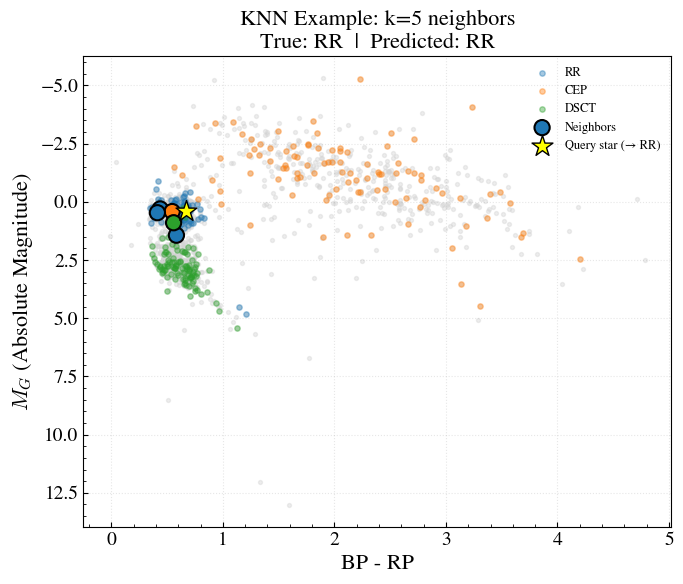

In [14]:
# ── Pick a random star from the test set ──────────────────
rng      = np.random.default_rng(seed=7)
idx      = rng.choice(X_test.index)
star     = X_test.loc[[idx]]
true_cls = y_test.loc[idx]

# ── Find the k nearest neighbors ───────────────────────
# KNN stores distances in feature space (unscaled if no scaler was used)
distances, neighbor_indices = knn.kneighbors(star)
neighbors     = X_train.iloc[neighbor_indices[0]]   # ← X_train
neighbor_lbls = y_train.iloc[neighbor_indices[0]]   # ← y_train
predicted_cls = knn.predict(star)[0]

for i, (ni, dist) in enumerate(zip(neighbor_indices[0], distances[0])):
    nb = X_train.iloc[ni]                            # ← X_train
    print(f"{i+1:<10} {nb['bp_rp']:>8.3f} {nb['Mg']:>8.3f} {dist:>10.4f} {y_train.iloc[ni]:>12}")


fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(df['bp_rp'], df['Mg'], c='lightgray', alpha=0.4, s=8, zorder=1)

for cls, color in color_classes.items():
    mask = y_test == cls
    ax.scatter(X_test.loc[mask, 'bp_rp'], X_test.loc[mask, 'Mg'],
               c=color, alpha=0.4, s=15, zorder=2, label=cls)

# Nearest neighbors
ax.scatter(neighbors['bp_rp'], neighbors['Mg'],
           c=[color_classes[l] for l in neighbor_lbls],
           s=120, edgecolors='black', linewidths=1.5, zorder=4, label='Neighbors')

# Lines from query star to each neighbor
for _, nb in neighbors.iterrows():
    ax.plot([star['bp_rp'].values[0], nb['bp_rp']],
            [star['Mg'].values[0],    nb['Mg']],
            'k--', lw=0.8, alpha=0.5, zorder=3)

# Query star
ax.scatter(star['bp_rp'], star['Mg'],
           c='yellow', edgecolors='black', s=250,
           zorder=5, marker='*', label=f'Query star (→ {predicted_cls})')

ax.invert_yaxis()
ax.set_xlabel('BP - RP')
ax.set_ylabel('$M_G$ (Absolute Magnitude)')
ax.set_title(f'KNN Example: k={knn.n_neighbors} neighbors\nTrue: {true_cls}  |  Predicted: {predicted_cls}')
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

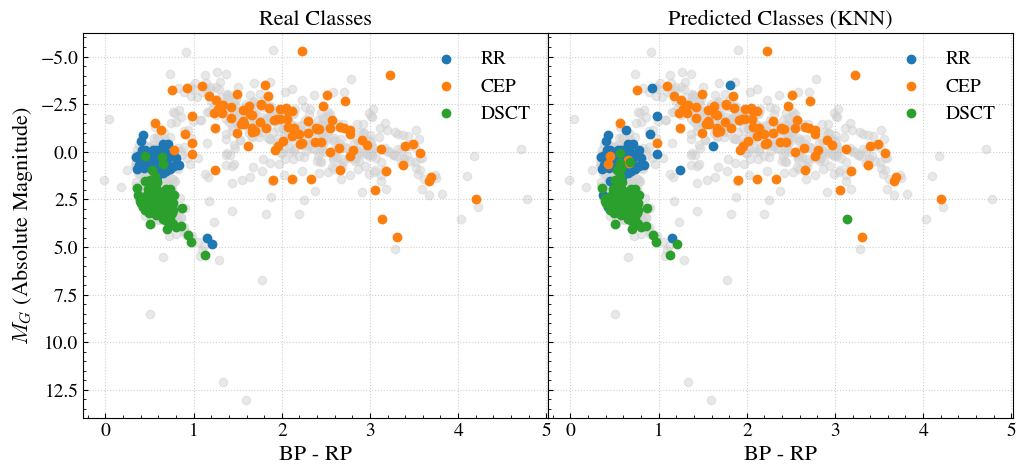

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, gridspec_kw={'wspace': 0})

for ax, labels, title in zip(axes,[y_test, y_pred],['Real Classes', 'Predicted Classes (KNN)']):

    ax.scatter(df['bp_rp'], df['Mg'],c='lightgray',  alpha=0.5, zorder=1)
    for cls, color in color_classes.items():
        mask = labels == cls
        ax.scatter(X_test.loc[mask, 'bp_rp'],X_test.loc[mask, 'Mg'],
                   c=color, label=cls, zorder=2
                   )

    ax.set_xlabel('BP - RP')
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid()

axes[0].invert_yaxis()
axes[0].set_ylabel('$M_G$ (Absolute Magnitude)')
plt.show()

A powerful way to visually assess classifier performance is the **confusion matrix**. For a problem with $C$ classes, it is a $C \times C$ matrix $\mathbf{M}$ where each entry $M_{ij}$ counts the number of samples whose **true class is $i$** and were **predicted as class $j$**:

The diagonal entries $M_{ii}$ represent **correct classifications**, while off-diagonal entries reveal **where and how the model confuses classes**.

Reading the matrix:
- A **dark diagonal** → the model separates classes well
- A bright off-diagonal cell $M_{ij}$ → the model systematically confuses class $i$ for class $j$

In our three-class problem (CEP, RR Lyrae, DSCT), the confusions have distinct physical interpretations:

- **CEP ↔ RR Lyrae:** Both are radially pulsating stars lying within the classical instability strip. Their period–luminosity sequences overlap at short periods, making photometric separation challenging.
- **CEP ↔ DSCT:** Cepheids are evolved supergiants, while Delta Scuti stars are main-sequence A–F stars.Confusion here suggests the model is not effectively using the absolute magnitude $M_G$ (parallax-derived luminosity).
- **RR ↔ DSCT:** RR Lyrae are old, metal-poor horizontal branch stars, while DSCT are young Population I stars. Confusion in this pair would indicate poor use of color ($BP-RP$) or proper motion features

`sklearn` provides two convenient tools to compute and display it.

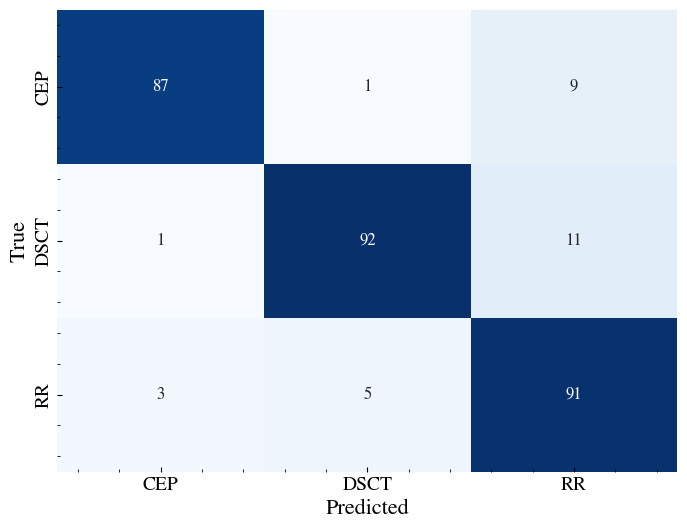

In [16]:
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots()
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_, cbar=False, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.show()

We now compute the standard classification metrics: precision, recall, F1-score, and accuracy. For a given class $c$, we define:

- **True Positives (TP):** samples of class $c$ correctly predicted as $c$
- **False Positives (FP):** samples of other classes incorrectly predicted as $c$
- **False Negatives (FN):** samples of class $c$ incorrectly predicted as another class
- **True Negatives (TN):** samples not of class $c$ correctly predicted as not $c$

The metrics are then defined as:
- **Precision (Purity):** Precision measures the accuracy of positive predictions. It answers: Of all stars flagged as class $c$, how many actually belong to it?
    $$\text{Precision} = \frac{TP}{TP + FP}$$
    High Precision indicates a "clean" sample with low contamination from other stellar types.

- **Recall (Completeness / Sensitivity):** Recall measures the ability of the model to find all instances of a class. It answers: Of all actual stars of class $c$ in the dataset, how many did the model correctly identify?
    $$\text{Recall} = \frac{TP}{TP + FN}$$
    High Recall is crucial when the goal is to create an exhaustive catalog of a specific variability type.

- **F1-Score:** The F1-score is the harmonic mean of Precision and Recall. It provides a single score that balances both metrics, which is particularly useful when dealing with imbalanced classes (e.g., when Cepheids are much rarer than Delta Scuti stars).
    $$\text{F1-score} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2\,TP}{2\,TP + FP + FN}$$

- **Accuracy (Exactitude):** Accuracy represents the proportion of total correct predictions across all classes.
    $$\text{Accuracy} = \frac{\sum_c TP_c}{N} = \frac{\text{correctly classified samples}}{\text{total samples}}$$
    Accuracy can be misleading if the dataset is highly imbalanced, as a model could achieve high accuracy by simply predicting the majority class.


For CEP — $TP=81,\ FP=1+3=4,\ FN=5+15=20$

$$\text{Precision}_{CEP} = \frac{81}{81+4} = \frac{81}{85} \approx 0.953$$

$$\text{Recall}_{CEP} = \frac{81}{81+20} = \frac{81}{101} \approx 0.802$$

$$\text{F1}_{CEP} = \frac{2\times81}{2\times81+4+20} = \frac{162}{186} \approx 0.871$$

For DSCT — $TP=84,\ FP=5+20=25,\ FN=1+7=8$

$$\text{Precision}_{DSCT} = \frac{84}{84+25} = \frac{84}{109} \approx 0.771$$

$$\text{Recall}_{DSCT} = \frac{84}{84+8} = \frac{84}{92} \approx 0.913$$

$$\text{F1}_{DSCT} = \frac{2\times84}{2\times84+25+8} = \frac{168}{201} \approx 0.836$$

For RR — $TP=84,\ FP=15+7=22,\ FN=3+20=23$

$$\text{Precision}_{RR} = \frac{84}{84+22} = \frac{84}{106} \approx 0.792$$

$$\text{Recall}_{RR} = \frac{84}{84+23} = \frac{84}{107} \approx 0.785$$

$$\text{F1}_{RR} = \frac{2\times84}{2\times84+22+23} = \frac{168}{213} \approx 0.789$$





For multi-class problems (as in our case: RR, CEP, DSCT/GDOR/SXPHE), these metrics are computed **per class** and then averaged. `classification_report` uses **macro averaging** by default:

$$\overline{\text{F-1}} = \frac{1}{C} \sum_{c=1}^{C} \text{F-1}_c$$

where $C$ is the number of classes.
skelarn tiene dentro de su mismo código una forma calcular las metricas por si mismo a través de moetodo

from sklearn.metrics import classification_report

In [17]:
# Finally, we will evaluate the performance of the classifier on the test set
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         CEP       0.96      0.90      0.93        97
        DSCT       0.94      0.88      0.91       104
          RR       0.82      0.92      0.87        99

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.91      0.90      0.90       300



## ROC Curve (Receiver Operating Characteristic)
The ROC Curve is a diagnostic tool used to visualize the performance of a binary (or multi-class One-vs-Rest) classifier as the decision threshold ($\tau$) varies.In a KNN model, classification is based on local proportions. For example, if you set $k=10$ and 7 neighbors belong to the 'CEP' class, the model assigns a probability of $0.7$ to that class.If your threshold is $\tau = 0.5$, the star is classified as 'CEP'.If you raise the threshold to $\tau = 0.8$, the same star would be classified as "Other."The ROC curve is generated by calculating the following metrics across all possible thresholds between 0 and 1:$$TPR = \frac{TP}{TP+FN} \qquad FPR = \frac{FP}{FP+TN}$$TPR (True Positive Rate / Sensitivity): The proportion of actual positives correctly identified.FPR (False Positive Rate): The proportion of actual negatives incorrectly identified as positives.

**AUC (Area Under the Curve):** The AUC is a scalar value that summarizes the overall performance displayed in the ROC plot. Mathematically, it represents the probability that the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.It is calculated as the integral of the ROC curve:
$$AUC = \int_{0}^{1} TPR(FPR) \, dFPR$$
Interpretation of Values:
- $AUC = 1.0$: A perfect classifier. It achieves total separation between classes with zero overlap.
- $0.7 < AUC < 0.9$: A robust model with high discriminative power.
- $AUC = 0.5$: A random classifier (equivalent to a coin flip). This is represented by the diagonal dashed line on the graph.

**Gini:** The Gini Index is a metric derived from the AUC, used to quantify how much better the model performs compared to a random baseline. While the AUC ranges from 0.5 to 1.0 for useful models, the Gini index is normalized so that the baseline (random chance) is equal to zero.The mathematical relationship is defined as:
$$\text{Gini} = 2 \cdot AUC - 1$$
- Range: The Gini index operates within the $[0, 1]$ interval.
- $Gini = 0$: The model offers no improvement over random chance ($AUC = 0.5$).
- $Gini = 1$: The model is perfect ($AUC = 1.0$).

In the context of variable star classification, a high Gini index indicates that the selected feature space (colors, magnitudes, parallaxes) is highly informative, allowing for a clear physical distinction between different stellar populations.

Evaluation for 3 classes: ['CEP' 'DSCT' 'RR']

Binary Labels
Shape: (300, 3) (Sample: 300, Classes: 3)
Example of binary labels (first 5 rows):
[[0 1 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]
 [1 0 0]]


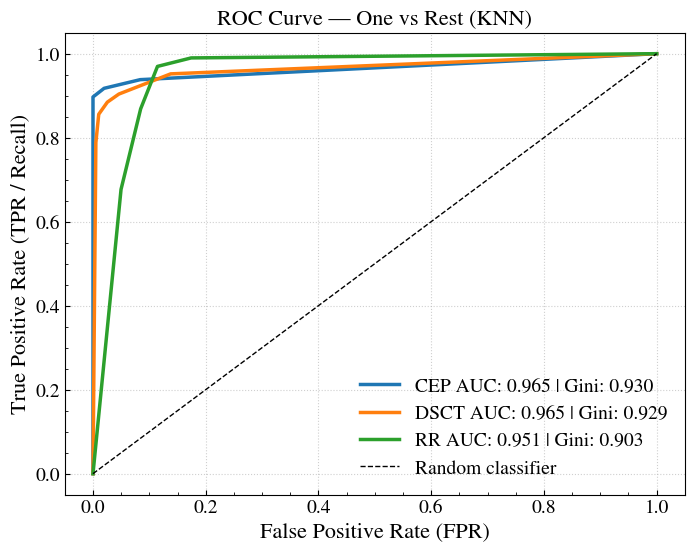

Class                   AUC   Gini
-----------------------------------
CEP                   0.965  0.930
DSCT                  0.965  0.929
RR                    0.951  0.903


In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


classes   = knn.classes_
n_classes = len(classes)

print(f"Evaluation for {n_classes} classes: {classes}")

# The ROC curve requires a binary format for the labels (One-vs-Rest) for each class.
# Transform 'CEP' -> [1, 0, 0], 'RR' -> [0, 1, 0], 'DSCT' -> [0, 0, 1]

y_test_bin = label_binarize(y_test, classes=classes)
print("\nBinary Labels")

print(f"Shape: {y_test_bin.shape} (Sample: {y_test_bin.shape[0]}, Classes: {y_test_bin.shape[1]})")
print(f'Example of binary labels (first 5 rows):\n{y_test_bin[:5]}')

# Predicted probabilities (required for ROC)
y_prob = knn.predict_proba(X_test)

# Compute ROC and AUC per class
fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, color_classes.values())):
    # Compute FPR, TPR and thresholds for the current class
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    gini    = 2 * roc_auc - 1
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{cls} AUC: {roc_auc:.3f} | Gini: {gini:.3f}')

# Random classifier line
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR / Recall)')
ax.set_title('ROC Curve — One vs Rest (KNN)')
ax.legend(frameon=False,loc='lower right')
ax.grid()

plt.show()

# Numerical summary
print(f"{'Class':<20} {'AUC':>6} {'Gini':>6}")
print("-" * 35)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"{cls:<20} {roc_auc:>6.3f} {2*roc_auc-1:>6.3f}")

## Decision Tree 

A Decision Tree is a non-parametric supervised learning algorithm that performs classification by recursively partitioning the feature space into disjoint rectangular regions. Each internal node represents a "test" on an attribute (e.g., Is absolute magnitude $M_G < 4.0$?), each branch represents the outcome of the test, and each leaf node represents a final class label (e.g., RR Lyrae).

The algorithm uses a Greedy Approach called Recursive Binary Splitting. At each node, it evaluates all possible features ($M_G$, $BP-RP$, $\varpi$, etc.) and all possible threshold values ($v$) to find the split that results in the "purest" child nodes.The goal is to move from a state of high uncertainty (a mix of all star types) to a state of high certainty (nodes containing only one type of star).

**Gini Impurity:** The default criterion for most implementations (including `scikit-learn`) is Gini Impurity. It measures the probability of a randomly chosen element from the set being incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.For a node with $C$ classes, the Gini Impurity $G$ is defined as:

$$G = 1 - \sum_{c=1}^{C} p_c^2$$

$$G_{max} = 1 - C \cdot \left(\frac{1}{C}\right)^2 = 1 - \frac{1}{C}$$

Example for your 3 classes: $G_{max} = 1 - \frac{1}{3} = 0.666$. If you see this value in a node, the model has no idea what that star is.

Where $p_c$ is the proportion of samples belonging to class $c$ in that specific node.
- $G = 0$: A "pure" node. All stars belong to the same class (e.g., 100% Cepheids).
- $G$ is maximized: When classes are perfectly mixed (e.g., 33% of each for 3 classes).

**Entropy (Information Theory):** An alternative to Gini is Entropy, which originates from Shannon's Information Theory. It measures the average "information" or "uncertainty" contained in the data.

The Entropy H of a node is calculated as:

$$H = - \sum_{c=1}^{C} p_c \log_2(p_c)$$

To decide the best split, the algorithm calculates the Information Gain (IG), which is the reduction in entropy achieved by partitioning the data according to a feature f:

$$IG(parent, f) = H(parent) - \sum_{i=1}^{k} \frac{N_i}{N_{total}} H(child_i)$$

The main hyperparameter controlling model complexity is `max_depth` — the maximum number of successive splits allowed. Without a limit, the tree will grow until every leaf is pure, **memorizing the training data** (overfitting).

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)

# Evaluate
y_pred_dtree = dtree.predict(X_test)
print(classification_report(y_test, y_pred_dtree))


              precision    recall  f1-score   support

         CEP       0.98      0.98      0.98        97
        DSCT       0.96      0.95      0.96       104
          RR       0.95      0.96      0.95        99

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



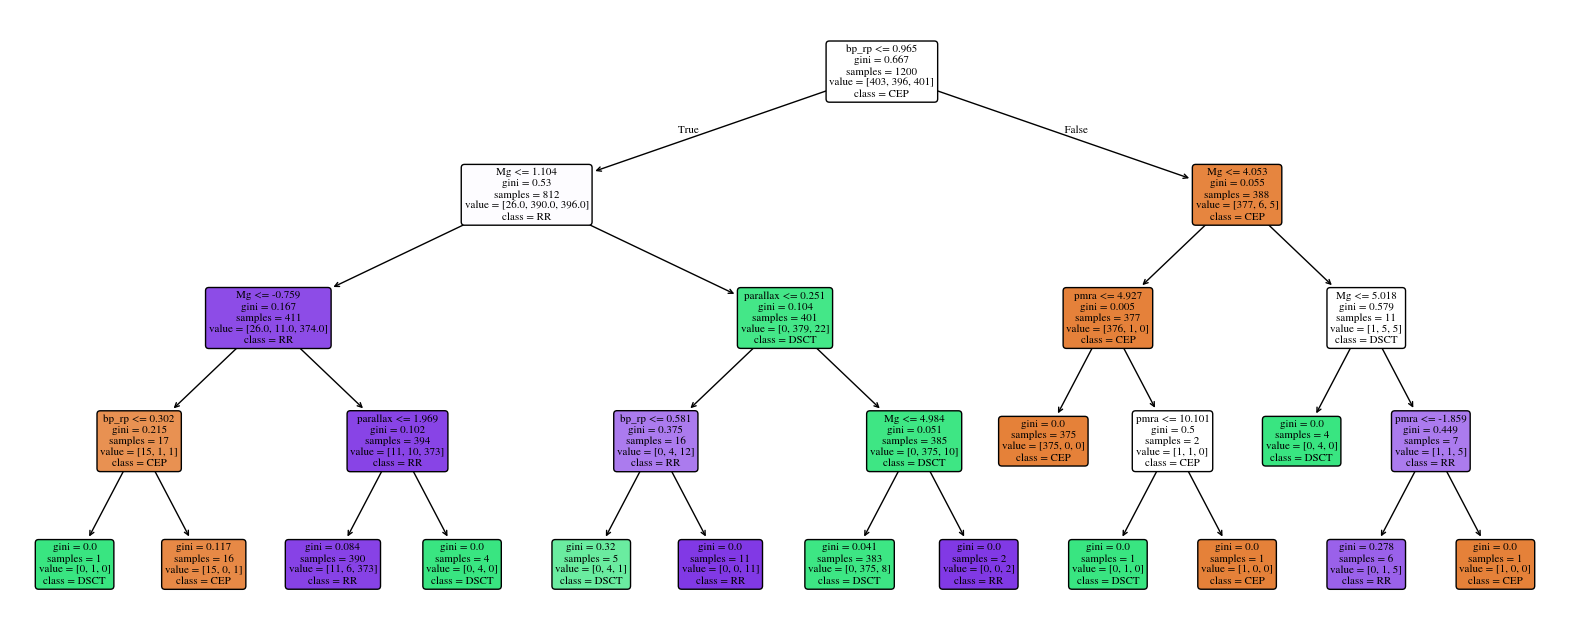

--- Decision path for star 58 ---
Node  0: Is bp_rp > 0.9649? (Actual value: 2.2308) -> Go right
Node 16: Is Mg ≤ 4.0528? (Actual value: -5.2882) -> Go left
Node 17: Is pmra ≤ 4.9270? (Actual value: -3.3670) -> Go left
--> Leaf Node 18: Final classification = CEP


In [22]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dtree,
          feature_names=X.columns.tolist(),
          class_names=dtree.classes_,
          filled=True,
          rounded=True,
          ax=ax)
plt.show()

# Select one object from the test set to analyze its path through the tree
sample_idx = np.random.randint(0, len(X_test))  # You can change this index to select a different sample
sample = X_test.iloc[sample_idx:sample_idx+1]
node_indicator = dtree.decision_path(sample)
leaf_id = dtree.apply(sample)  # Final node (leaf)
node_indices = node_indicator.indices

print(f"--- Decision path for star {y_test.index[sample_idx]} ---")

# 2. Iterate over the nodes in the path
for node_id in node_indices:
    # If the node is a leaf, we are finished
    if leaf_id[0] == node_id:
        print(f"--> Leaf Node {node_id}: Final classification = {dtree.predict(sample)[0]}")
        break

    # Get the rule for the current node
    feature = dtree.tree_.feature[node_id]
    threshold = dtree.tree_.threshold[node_id]
    feature_name = X.columns[feature]
    value = sample.values[0][feature]

    # Determine if it went left (True) or right (False)
    if value <= threshold:
        direction = "≤"
        next_step = "left"
    else:
        direction = ">"
        next_step = "right"

    print(f"Node {node_id:2}: Is {feature_name} {direction} {threshold:.4f}? "
          f"(Actual value: {value:.4f}) -> Go {next_step}")

One key advantage of Decision Trees over KNN is their ability to quantify **how much each feature contributes to the classification**. This is known as *feature importance* (or *Gini importance*).

Every time a node splits on feature $f$, the impurity of the data decreases. The importance of feature $f$ is the **total weighted Gini reduction** it roduces across all nodes in the tree:

$$\text{importance}(f) = \sum_{\substack{t \in \text{nodes} \\ \text{split on } f}} \frac{N_t}{N} \,\Delta G_t$$

where $N_t$ is the number of samples reaching node $t$, $N$ is the total number of training samples, and $\Delta G_t$ is the Gini reduction at that node:

$$\Delta G_t = G_t - \frac{N_L}{N_t} G_L - \frac{N_R}{N_t} G_R$$

with $L$ and $R$ denoting the left and right child nodes respectively.

The importances are then **normalized** so that they sum to 1:

$$\sum_{f} \text{importance}(f) = 1$$

**Interpreting the values:**
- A feature with high importance → the tree relies heavily on it to separate classes
- A feature with near-zero importance → it adds little discriminating power and could potentially be removed

In our stellar classification problem, we expect $M_G$ (absolute magnitude) and $BP-RP$ (color) to dominate, since they directly locate a star on the HR diagram within the instability strip. Proper motions ($\mu_\alpha$, $\mu_\delta$) and parallax ($\varpi$) may provide secondary separation between populations of different ages and kinematics (e.g., old halo RR Lyrae vs. young disk Cepheids).

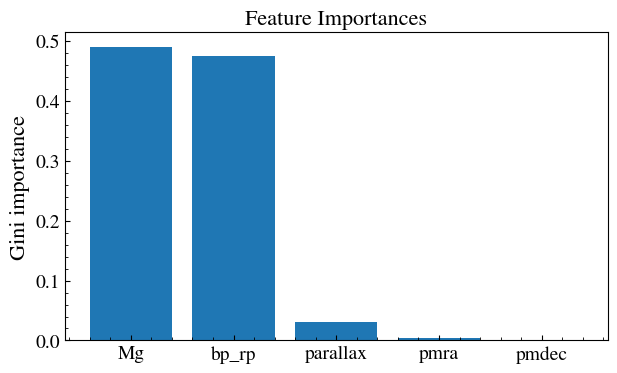

In [23]:
importances = dtree.feature_importances_
indices     = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar(X.columns[indices], importances[indices])
plt.title("Feature Importances")
plt.ylabel("Gini importance")
plt.show()

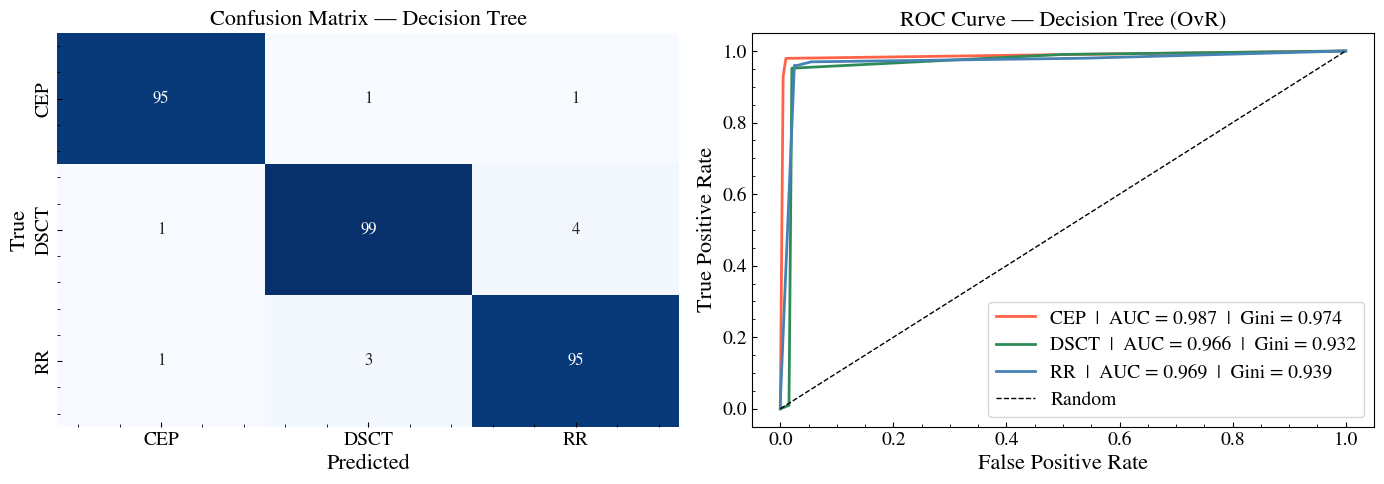

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. CONFUSION MATRIX ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_dtree, labels=dtree.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=dtree.classes_, yticklabels=dtree.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix — Decision Tree')

# ── 2. ROC CURVE (One-vs-Rest) ───────────────────────────────────
y_test_bin = label_binarize(y_test, classes=dtree.classes_)
y_prob_dtree  = dtree.predict_proba(X_test)

colors = ['tomato', 'seagreen', 'steelblue']

for i, (cls, color) in enumerate(zip(dtree.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dtree[:, i])
    roc_auc     = auc(fpr, tpr)
    gini        = 2 * roc_auc - 1
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{cls}  |  AUC = {roc_auc:.3f}  |  Gini = {gini:.3f}')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Decision Tree (OvR)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Why Random Forest over a Single Decision Tree?

A single Decision Tree, if grown without constraints, will **perfectly classify every training sample** — it simply memorizes the data. This is the classical overfitting problem: the model fits noise rather than the underlying signal, and generalizes poorly to new observations.

### The Core Problem: High Variance

A Decision Tree is a **high-variance** estimator. A small change in the training set (e.g., removing a few stars or adding new ones) can produce a completely different tree structure. This instability makes a single tree an unreliable classifier for scientific applications such as building stellar catalogs.

### The Solution: Ensemble Learning via Bagging

Random Forest addresses this by combining $B$ independent trees, each trained on a **bootstrap sample** — a random subset of the training data drawn *with replacement*:

$$\hat{y}(\mathbf{x}) = \underset{c}{\arg\max} \sum_{b=1}^{B} \mathbf{1}
\left[ T_b(\mathbf{x}) = c \right]$$

where $T_b(\mathbf{x})$ is the prediction of the $b$-th tree. The final class is determined by **majority vote** across all $B$ trees.

This technique is called **Bagging** (Bootstrap AGGregatING), and it reduces variance without significantly increasing bias:

$$\text{Var}\!\left(\frac{1}{B}\sum_{b=1}^B T_b\right) \approx \frac{\rho\,\sigma^2}{B}$$

where $\sigma^2$ is the variance of a single tree and $\rho$ is the correlation between trees. This shows two things:
- More trees ($B \uparrow$) → lower variance
- Less correlated trees ($\rho \downarrow$) → lower variance

### The Extra Trick: Random Feature Subsampling

To decorrelate the trees, at each split Random Forest only considers a **random subset of $m$ features** (instead of all $p$ features):

$$m \approx \sqrt{p} \quad \text{(classification default)}$$

This prevents all trees from always splitting on the same dominant feature (e.g., $M_G$), forcing them to explore different regions of the feature space and producing more diverse, less correlated trees.

### Decision Tree vs. Random Forest

| Property | Decision Tree | Random Forest |
|---|---|---|
| Variance | High | Low |
| Bias | Low | Low |
| Overfitting risk | High | Low |
| Interpretability | High (visualizable) | Low (black box) |
| Feature importance | Yes (single path) | Yes (averaged, more robust) |
| Training cost | Low | Higher ($\times B$) |

In our stellar classification context, Random Forest is preferred because a single tree may draw its boundaries based on statistical fluctuations in the Gaia sample (noisy parallaxes, crowded fields), whereas averaging over hundreds of trees produces a **more stable classification of the instability strip**.

Beyond the methods covered in this notebook, scikit-learn offers a wide range of supervised classification algorithms, each occupying a different position in the **bias–variance tradeoff** and making different trade-offs between complexity, interpretability, and computational cost.

A summary:

| Method | Bias | Variance | Interpretability | Cost |
|---|---|---|---|---|
| Logistic Regression | High | Low | High | Low |
| K-Nearest Neighbors | Low | High | Medium | Low (train) / High (predict) |
| Decision Tree | Low | High | High | Low |
| Random Forest | Low | Low | Low | Medium |
| Support Vector Machine | Medium | Low | Low | High |
| Gradient Boosting (XGBoost) | Low | Low | Low | High |
| Neural Network | Low | Low | Very Low | Very High |

We encourage you to explore the full list of classifiers and their hyperparameters in the official scikit-learn documentation:
[https://scikit-learn.org/stable/supervised_learning.html](https://scikit-learn.org/stable/supervised_learning.html)

## Cross-Validation

All metrics computed so far (accuracy, F1, ROC) were evaluated on a **single test set** defined by one `train_test_split`. 
This introduces a risk: the results may be **optimistic or pessimistic by chance**, depending on which stars happened to fall in the test set.

**Stratified K-Fold Cross-Validation** solves this by repeating the train/test evaluation $K$ times on different, non-overlapping partitions:

$$\text{CV Score} = \frac{1}{K} \sum_{k=1}^{K} \mathcal{L}(M_k, \mathcal{D}_k^{\text{test}})$$

where $M_k$ is the model trained on all folds except $k$, and $\mathcal{D}_k^{\text{test}}$ is the $k$-th held-out fold.

The **Stratified** variant ensures that each fold preserves the original class proportions — critical here since our three stellar classes (CEP, RR, DSCT) may not be perfectly balanced.

$$\frac{|\text{CEP in fold } k|}{|\text{fold } k|} \approx \frac{|\text{CEP total}|}{N}$$

The result is not a single accuracy value but a **distribution**:

$$\bar{s} \pm \sigma_s$$

A small $\sigma_s$ across folds indicates the model is **stable** — its performance does not depend heavily on which particular stars were used for training.

Model            Acc Mean Acc Std  Fold scores
                 F1 Mean F1 Std  F1 Fold scores
-------------------------------------------------------
KNN              0.9240 0.0106  [0.91666667 0.91333333 0.92666667 0.92       0.94333333]
                 0.9245 0.0105  [0.91740734 0.91400527 0.92673271 0.92057354 0.94371371]

Decision Tree    0.9547 0.0117  [0.94666667 0.97333333 0.96333333 0.94333333 0.94666667]
                 0.9547 0.0116  [0.94656521 0.97334859 0.96331457 0.94347286 0.94677976]



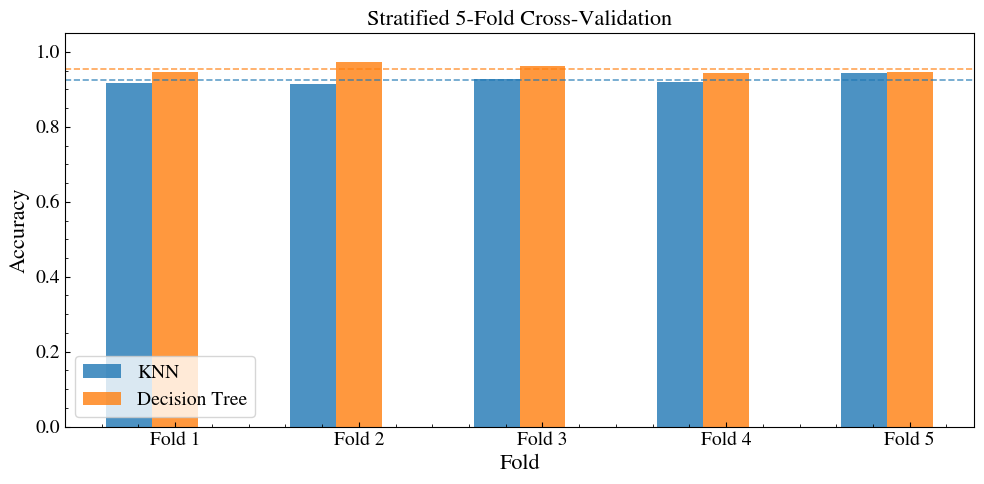

In [25]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
}
colors = {
    'KNN':           'C0',
    'Decision Tree': 'C1',
}

all_scores = {}
print(f"{'Model':<16} {'Acc Mean':>6} {'Acc Std':>6}  Fold scores")
print(f"{'':<16} {'F1 Mean':>6} {'F1 Std':>6}  F1 Fold scores")
print("-" * 55)
for name, clf in models.items():
    s = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')
    scores_f1 = cross_val_score(clf, X, y, cv=skf, scoring='f1_macro')
    all_scores[name] = s
    print(f"{name:<16} {s.mean():.4f} {s.std():.4f}  {s}")
    print(f"{'':<16} {scores_f1.mean():.4f} {scores_f1.std():.4f}  {scores_f1}")
    print()

x     = np.arange(1, 6)
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, (name, s) in enumerate(all_scores.items()):
    offset = (i - 1) * width
    ax.bar(x + offset, s, width=width, color=colors[name], alpha=0.8, label=name)
    ax.axhline(s.mean(), linestyle='--', color=colors[name], linewidth=1.2, alpha=0.7)

ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('Stratified 5-Fold Cross-Validation')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in x])
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [32]:
del df

NameError: name 'df' is not defined

# Regression
---

One of the most powerful empirical laws in observational astronomy is the **Period–Luminosity (P–L) relation**, also known as the **Leavitt Law**, first discovered by Henrietta Swan Leavitt in 1912 from observations of Cepheid variables in the Small Magellanic Cloud.

Leavitt found that brighter Cepheids pulsate more slowly — a tight, linear relationship between the logarithm of the pulsation period and the absolute magnitude:

$$M = \alpha \cdot \log_{10}(P) + \beta$$

where $M$ is the absolute magnitude, $P$ is the period in days, and $\alpha$, $\beta$ are empirically determined coefficients. This is not a coincidence: it reflects the underlying **stellar physics**. More luminous Cepheids are larger stars, and larger stars have longer dynamical timescales:

$$P \propto \frac{1}{\sqrt{G\bar{\rho}}} \implies \log P \propto -\frac{1}{2}\log\bar{\rho}$$

Since luminosity $L \propto R^2 T_{\text{eff}}^4$ and more massive stars are both larger and hotter, the period naturally correlates with luminosity.

This relation holds not only for **Classical Cepheids (CEP)**, but also for **RR Lyrae (RR)** stars, which define their own tighter P–L sequence at shorter periods ($P \sim 0.2$–$1$ day) and lower luminosities. Together, they form the foundation of the **cosmological distance ladder**:

$$d \, [\text{kpc}] = 10^{\frac{m - M + 5}{5}}$$

By fitting a regression model to the Gaia DR3 data, we can:
1. **Recover** the empirical $\alpha$ and $\beta$ coefficients
2. **Compare** the predictive power of Linear Regression, Decision Trees, and KNN
3. **Estimate distances** to new variable stars using only their observed period    and apparent magnitude

This makes regression on the P–L relation one of the most scientifically meaningful supervised learning exercises in stellar astrophysics.


In [33]:
q = """
SELECT TOP 2000
    g.source_id, g.phot_g_mean_mag, g.bp_rp, g.parallax,
    v.best_class_name AS target_class,
    COALESCE(rr.pf, cep.p1_t) AS frequency
FROM gaiadr3.gaia_source AS g
JOIN gaiadr3.vari_classifier_result AS v ON g.source_id = v.source_id
LEFT JOIN gaiadr3.vari_rrlyrae  AS rr  ON g.source_id = rr.source_id
LEFT JOIN gaiadr3.vari_cepheid  AS cep ON g.source_id = cep.source_id
WHERE v.best_class_name IN ('RR', 'CEP')
    AND g.parallax_over_error > 10
    AND g.bp_rp IS NOT NULL
    AND COALESCE(rr.pf, cep.p1_t) IS NOT NULL
"""

# Lanzar la consulta y convertir a DataFrame
job = Gaia.launch_job_async(q)
df = job.get_results().to_pandas()

# Limpieza de strings (de bytes a utf-8)
df['target_class'] = df['target_class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

500 Error 500:
null


HTTPError: Error 500:
null

For this regression exercise, we restrict our sample to **Classical Cepheids (CEP)** only, querying $N = 1000$ stars from Gaia DR3. We compare three supervised regression methods of increasing complexity:

1. **Linear Regression** — fits a straight line $\hat{y} = \alpha \log P + \beta$, the classical parametric form of the Leavitt Law.
2. **Decision Tree Regressor** — partitions the period space into rectangular bins and predicts the mean luminosity within each bin. It captures non-linear features of the P–L relation but is prone to overfitting.
3. **K-Nearest Neighbors Regressor** — predicts the luminosity of a new Cepheid by averaging the $k$ most similar stars in period space, with no assumed functional form.

This comparison allows us to evaluate both predictive accuracy (via MSE and $R^2$) and physical interpretability of each approach on a well-understood astrophysical relation.

In [24]:
print("Connecting to VizieR TAP...")
vizier_tap = TapPlus(url="http://tapvizier.cds.unistra.fr/TAPVizieR/tap")

q = """
SELECT TOP 1000
    g.Source AS source_id, 
    g."BP-RP" AS bp_rp, 
    v.Class AS target_class,
    cep.PF AS period
FROM "I/355/gaiadr3" AS g
INNER JOIN "I/358/vclassre" AS v ON g.Source = v.Source
INNER JOIN "I/358/vcep" AS cep ON g.Source = cep.Source
WHERE v.Class = 'CEP'
    AND (g.Plx / g.e_Plx) > 5
    AND g."BP-RP" IS NOT NULL
"""

job = vizier_tap.launch_job(q)
df = job.get_results().to_pandas()

df['target_class'] = df['target_class'].apply(
    lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x)
)

# ==========================================
# 2. PREPROCESAMIENTO (Sin usar distancias)
# ==========================================
# Unificar períodos (Ahora ambas vienen de columnas llamadas PF, pero con alias distintos)

# Limpiamos NaNs
df = df.dropna(subset=['period', 'bp_rp', 'target_class']).copy()

print(f"Datos listos: {len(df)} estrellas con período y color.")

Conectando con VizieR TAP...


Datos listos: 697 estrellas con período y color.


In [34]:
try:
    assert not df.empty
except (NameError, AssertionError):
    df = pd.read_csv('gaia_variable_stars_regression.csv')

In [35]:
df.columns

Index(['source_id', 'bp_rp', 'target_class', 'period'], dtype='str')

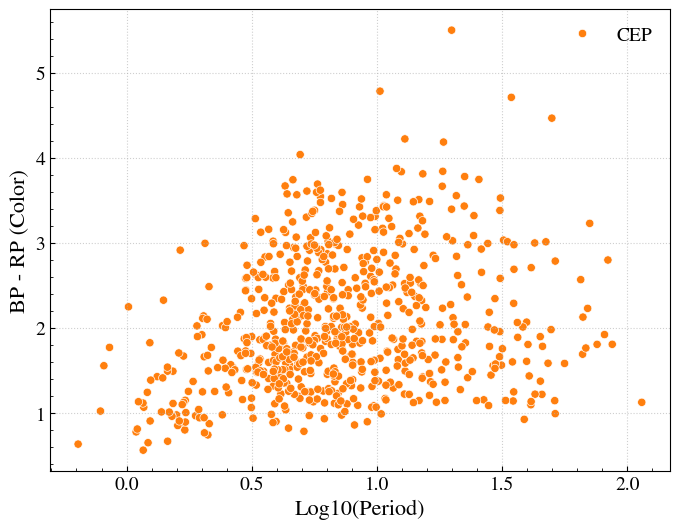

In [36]:
df['log_period'] = np.log10(df['period'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='log_period', y='bp_rp', hue='target_class', palette=color_classes)
ax.set_xlabel('Log10(Period)')
ax.set_ylabel('BP - RP (Color)')
ax.legend(title='', frameon=False)
ax.grid()
plt.show()

In [37]:
from sklearn.model_selection import train_test_split


X = df[['log_period']]
y = df['bp_rp']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

As introduced in a previous auxiliary session on Linear Regression, the first method we apply is `LinearRegression` from `scikit-learn`. Recall that a linear model assumes the target variable $y$ is a linear function of the input feature $x$:

$$\hat{y} = \alpha \cdot x + \beta$$

where the coefficients $\alpha$ (slope) and $\beta$ (intercept) are estimated by minimizing the **Residual Sum of Squares (RSS)**:

$$\hat{\alpha}, \hat{\beta} = \underset{\alpha,\, \beta}{\arg\min} \sum_{i=1}^{N} \left( y_i - \alpha x_i - \beta \right)^2$$

In our context, $x = \log_{10}(P)$ and $y = BP-RP$, so the fitted line directly recovers the empirical slope of the **Period–Color relation** for Classical Cepheids — a projection of the Leavitt Law onto the color axis.

Unlike KNN and Decision Trees, Linear Regression is a **parametric** model: it produces an interpretable closed-form solution and generalizes well when the underlying physical relation is truly linear. Its limitation here is that it cannot capture any non-linearity or intrinsic scatter in the P–L sequence.

Evaluación del modelo de regresión lineal:
R²: 0.0706
MSE: 0.5900
------------------------------
Color (BP-RP) = 1.6525 + 0.4725 * log(Period)


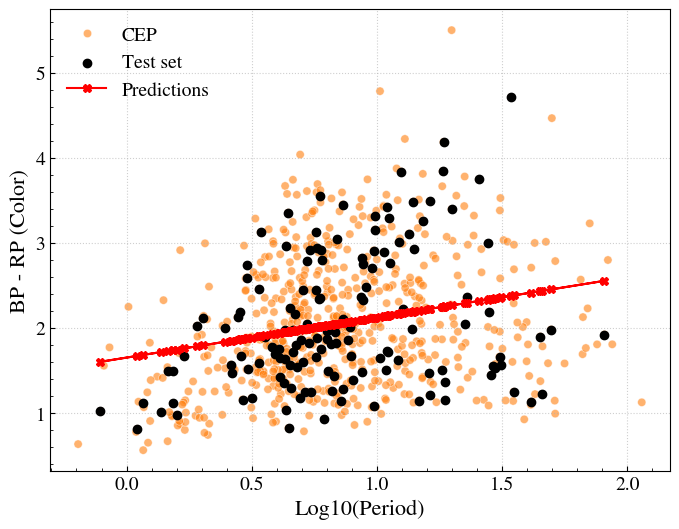

In [38]:
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


print("Evaluación del modelo de regresión lineal:")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print('-'*30)
print(f"Color (BP-RP) = {model.intercept_:.4f} + {model.coef_[0]:.4f} * log(Period)")


fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='log_period', y='bp_rp', hue='target_class', palette=color_classes, alpha=0.6, ax=ax)
ax.scatter(X_test['log_period'], y_test, color='black', label='Test set', zorder=5)
ax.plot(X_test['log_period'], y_pred, color='red', label='Predictions', zorder=6, marker='X')
ax.set_xlabel('Log10(Period)')
ax.set_ylabel('BP - RP (Color)')
ax.legend(title='', frameon=False)
ax.grid()
plt.show()

### K-Nearest Neighbors Regressor

The K-Nearest Neighbors (KNN) regressor is an empirical, instance-based algorithm known as *lazy learning*: it stores the entire training set during fit and defers all computation to prediction time, fitting no explicit parameters.

To predict the color $BP-RP$ of a new Cepheid at $\log P = x$, the algorithm computes the distance to every training point. In this one-dimensional case:

$$d(x, x_i) = |x - x_i|$$

It then identifies the $k$ closest neighbors $\mathcal{N}_k(x)$ and returns their average color:

$$\hat{y} = \frac{1}{k} \sum_{i \in \mathcal{N}_k(x)} y_i$$

Alternatively, weighting each neighbor inversely by distance (`weights='distance'`) gives physically closer stars more influence:

$$\hat{y} = \frac{\sum_{i} y_i / d_i}{\sum_{i} 1/d_i}$$

**Effect of $k$:**
- $k$ too small → overfitting: the model memorizes instrumental noise
- $k$ too large → underfitting: it averages over physically dissimilar stars, washing out the true P–L slope


Evaluation of the K-Nearest Neighbors (KNN) regression model:
R² Score: 0.1127
Mean Squared Error (MSE): 0.5632
----------------------------------------
Algorithm Type: Instance-based (Lazy Learning)
Hyperparameter used: k = 15 neighbors


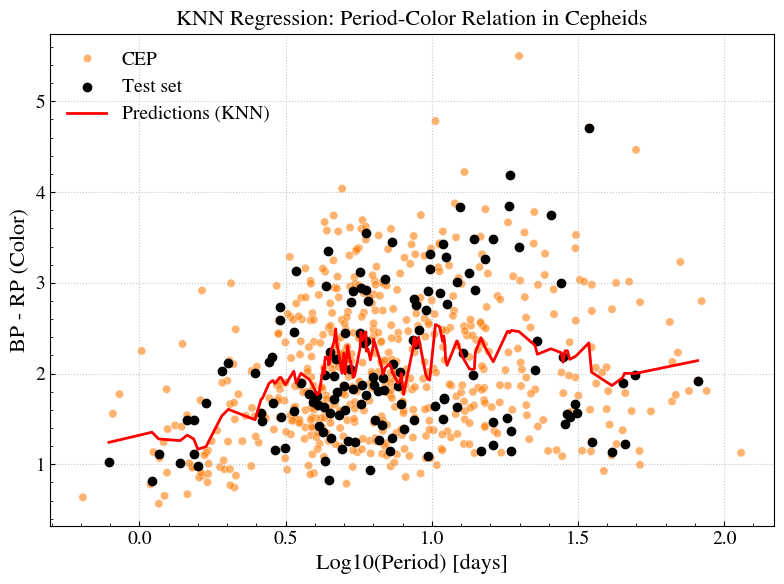

In [39]:
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. MODEL INITIALIZATION AND TRAINING
# ==========================================
# Define hyperparameter k
k_neighbors = 15

# Initialize, train, and predict
model = KNeighborsRegressor(n_neighbors=k_neighbors)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# ==========================================
# 2. MODEL EVALUATION
# ==========================================
print("Evaluation of the K-Nearest Neighbors (KNN) regression model:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print('-' * 40)
print(f"Algorithm Type: Instance-based (Lazy Learning)")
print(f"Hyperparameter used: k = {model.n_neighbors} neighbors")

# ==========================================
# 3. VISUALIZATION
# ==========================================
# Educational trick: Sort X_test by the feature (log_period) 
# so that ax.plot draws a continuous curve instead of a zigzag line.
X_test_sorted = X_test.sort_values(by='log_period')
y_pred_sorted = model.predict(X_test_sorted)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot background data (Training set and overall distribution)
sns.scatterplot(data=df, x='log_period', y='bp_rp', hue='target_class', 
                palette=color_classes, alpha=0.6, ax=ax)

# Highlight the specific test samples
ax.scatter(X_test['log_period'], y_test, color='black', label='Test set', zorder=5)

# Plot the KNN prediction curve
ax.plot(X_test_sorted['log_period'], y_pred_sorted, color='red', 
        label='Predictions (KNN)', zorder=6, linewidth=2)

ax.set_title('KNN Regression: Period-Color Relation in Cepheids')
ax.set_xlabel('Log10(Period) [days]')
ax.set_ylabel('BP - RP (Color)')
ax.legend(title='', frameon=False)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Decision Tree Regressor

The `DecisionTreeRegressor` learns to predict by recursively partitioning the feature space into disjoint intervals through a series of binary rules. In our Cepheid exercise, at each node the algorithm asks: *"At what value of $\log_{10}(P)$ can I split the stars to minimize the color spread within each resulting group?"*

**Split criterion — MSE reduction:** Unlike classification trees that minimize Gini impurity, a regression tree minimizes the **weighted Mean Squared Error** across the two child nodes:

$$\Delta\text{MSE}(t, v) = \text{MSE}(t) - \frac{N_L}{N_t}\,\text{MSE}(L) - \frac{N_R}{N_t}\,\text{MSE}(R)$$

where $t$ is the current node split at threshold $v$, and $L$, $R$ are the left and right children with $N_L$, $N_R$ samples respectively. The algorithm searches exhaustively over all features and thresholds and selects the $(f, v)$ pair that **maximizes** $\Delta\text{MSE}$.

**Prediction at a leaf node:** The tree grows by repeating this process until reaching terminal nodes (*leaves*). A new Cepheid descends the tree by answering each binary question (e.g., $\log P < 0.8$?) and arrives at a leaf $\ell$. The prediction is the mean color of all training stars that fell into that leaf:

$$\hat{y} = \frac{1}{|\ell|} \sum_{i \in \ell} y_i$$

A tree of depth $d$ produces at most $2^d$ leaves, partitioning the period axis into $2^d$ constant-valued segments — giving the characteristic **staircase shape** in the prediction curve.

**Overfitting and `max_depth`:** An unconstrained tree will grow until each leaf contains a single training star, achieving $R^2 = 1.0$ on the training set by memorizing instrumental noise and intrinsic scatter. This does not generalize. By setting `max_depth=3`, we restrict the tree to $2^3 = 8$ leaves — enough to capture the global slope and curvature of the P–L relation without overfitting individual stars.

Evaluation of the Decision Tree (Regression) model:
R²: 0.0689
MSE: 0.5911
------------------------------
Algorithm based on space partitioning (Orthogonal splits)
Hyperparameter used: max_depth = 3 levels


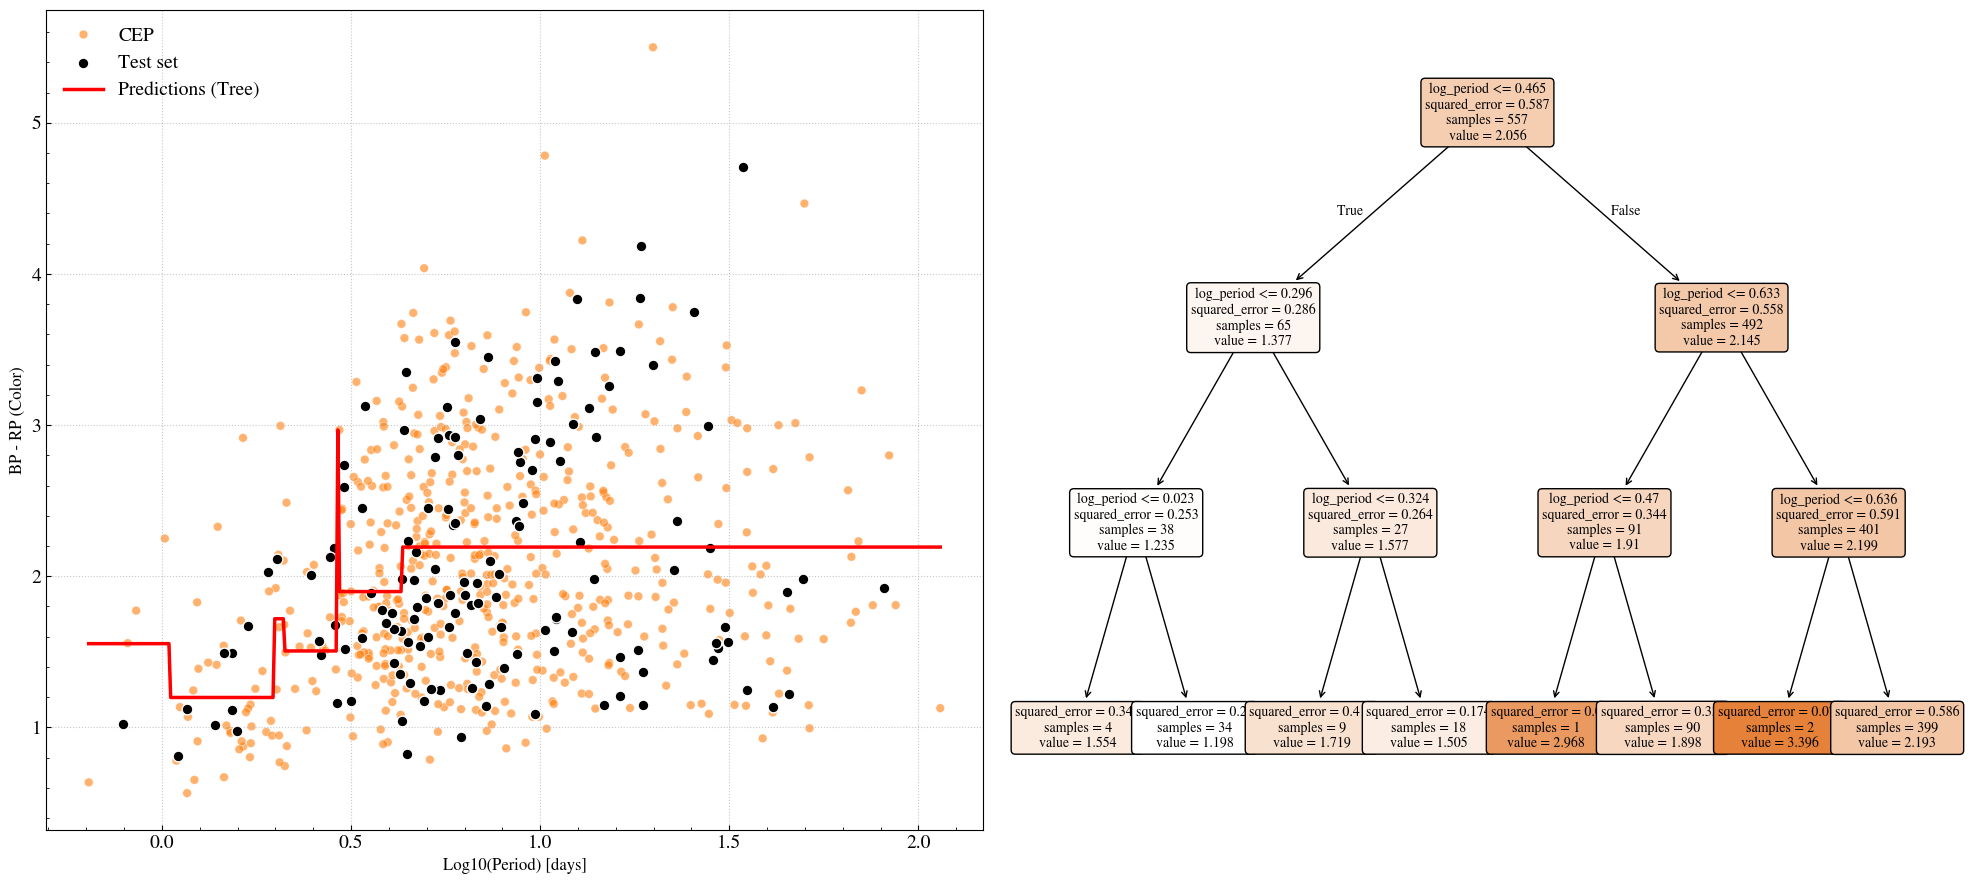

In [40]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define max depth to avoid overfitting
# Limit to 3 so the plot_tree diagram is readable
max_depth_val = 3
model = DecisionTreeRegressor(max_depth=max_depth_val, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Evaluation of the Decision Tree (Regression) model:")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print('-'*30)
print(f"Algorithm based on space partitioning (Orthogonal splits)")
print(f"Hyperparameter used: max_depth = {model.max_depth} levels")

# Generate a dense grid for smooth staircase visualization
x_min, x_max = df['log_period'].min(), df['log_period'].max()
X_grid = np.linspace(x_min, x_max, 500).reshape(-1, 1)
X_grid_df = pd.DataFrame(X_grid, columns=['log_period'])
y_pred_grid = model.predict(X_grid_df)

# ==============================================================================
# FINAL PLOT CONFIGURATION (2 Columns: [Regression | Structure])
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# ------------------------------------------------------------------------------
# Plot 1 (Left): Visual Regression (The Staircase)
# ------------------------------------------------------------------------------
ax = axes[0] 

# Original data (background)
sns.scatterplot(data=df, x='log_period', y='bp_rp', hue='target_class', 
                palette=color_classes, alpha=0.6, ax=ax, s=40)

# Test set
ax.scatter(X_test['log_period'], y_test, color='black', label='Test set', zorder=5, s=60, edgecolor='w')

# Tree prediction curve (Staircase shape)
ax.plot(X_grid_df['log_period'], y_pred_grid, color='red', label='Predictions (Tree)', zorder=6, lw=2.5)

ax.set_xlabel('Log10(Period) [days]', fontsize=12)
ax.set_ylabel('BP - RP (Color)', fontsize=12)
ax.legend(title='', frameon=False, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.7)

# ------------------------------------------------------------------------------
# Plot 2 (Right): Mathematical Structure (The Tree Diagram)
# ------------------------------------------------------------------------------
ax = axes[1] 
plot_tree(model, 
          ax=ax,
          feature_names=['log_period'],
          filled=True,
          rounded=True,
          fontsize=10 
          )

plt.tight_layout()
plt.show()